In [133]:
import numpy as np
from scipy.stats import f, norm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

 # Вариант 41
 ## Задание 1
 ### Исходные данные:
 - $X_1 \sim \mathcal{N}(\mu_1, \sigma_1^2)$, где $\mu_1=0, \sigma_1^2=2$
- $X_2 \sim \mathcal{N}(\mu_2, \sigma_2^2)$, где $\mu_2=0, \sigma_2^2=1$

Известны $\mu_1, \mu_2$, поэтому можно использовать точные выражения для сумм квадратов отклонений.

### Немного теории
>**Распределение Фишера $F$**<br/>
Пусть $X_1, \dots, X_n \sim \mathcal{N}(0, 1)$, $Y_1, \dots, Y_m \sim \mathcal{N}(0, 1)$<br/>
  Тогда величины $Z_1 = \sum\limits_{i=1}^{n} X_i^2$ и $Z_2 = \sum\limits_{i=1}^{m} Y_i^2$ будут иметь распределения $\chi_n^2$ и $\chi_m^2$ соответственно, а величина
$$F = \frac{\frac{Z_1}{n}}{\frac{Z_2}{m}}$$
будет иметь распределение Фишера со степенями свободы $n, m$.

### Доверительный интервал
Функция
$$
\frac{n_2\sum\limits_{i=1}^{n_1}(X_{1,i}-μ_1)^2}{n_1\sum\limits_{i=1}^{n_2} (X_{2,i}-μ_2)^2}\cdot \frac{σ_2^2}{σ_1^2}
$$

Для нормально распределенных данных с известным средним $μ$:
$$
\frac{\sum\limits_{i=1}^{n_1} (X_{1,i}-μ_1)^2}{σ_1^2} ∼ χ^2(n_1),\quad
\frac{\sum\limits_{i=1}^{n_2} (X_{2,i}-μ_2)^2}{σ_2^2} ∼ χ^2(n_2)
$$

Отношение двух $χ^2$, делённых на степени свободы это распределение Фишера $F(n_1, n_2)$:

$$
\frac{\frac{\sum\limits_{i=1}^{n_1} (X_{1,i}-μ_1)^2}{σ_1^2}/n_1}{\frac{\sum\limits_{i=1}^{n_2} (X_{2,i}-μ_2)^2}{σ_2^2}/n_2} \sim F(n_1, n_2)
$$

Тогда:

$$
\frac{n_2\sum\limits_{i=1}^{n_1}(X_{1,i}-μ_1)^2}{n_1\sum\limits_{i=1}^{n_2} (X_{2,i}-μ_2)^2}\cdot \frac{σ_2^2}{σ_1^2} \sim F(n_1, n_2)
$$

Сделаем замену:
$$
S_1^2 = \frac{\sum\limits_{i=1}^{n_1} (X_{1,i}-μ_1)^2}{n_1},\quad
S_2^2 = \frac{\sum\limits_{i=1}^{n_2} (X_{2,i}-μ_1)^2}{n_2}
$$

$$
\frac{S_1^2}{S_2^2}\cdot \frac{σ_2^2}{σ_1^2} = \frac{S_1^2}{S_2^2}\cdot \frac{1}{τ} \sim F(n_1, n_2)
$$

Из распределения Фишера:

$$
P(F_{α/2}(n_1, n_2) ≤ \frac{S_1^2}{S_2^2} \frac{1}{τ} ≤ F_{1-α/2}(n_1, n_2)) = 1 - α
$$

$$
τ \in \left[\frac{S_1^2/S_2^2}{F_{1-α/2}(n_1, n_2)},  \frac{S_1^2/S_2^2}{F_{α/2}(n_1, n_2)}\right]
$$

In [134]:
mu_1 = 0
mu_2 = 0
sigma_1_sq = 2
sigma_2_sq = 1
tau = sigma_1_sq / sigma_2_sq
alpha = 0.05
n_small = 25
n_large = 10000
experiments = 1000
n_runs = 50

In [135]:
def simulate_experiment(n):
    coverage = 0
    lows = []
    highs = []

    for i in range(experiments):

        X_1 = np.random.normal(mu_1, np.sqrt(sigma_1_sq), n)
        X_2 = np.random.normal(mu_2, np.sqrt(sigma_2_sq), n)

        S_1_sq = np.sum((X_1 - mu_1)**2)/n
        S_2_sq = np.sum((X_2 - mu_2)**2)/n

        F_low = f.ppf(alpha/2, n, n)
        F_high = f.ppf(1-alpha/2, n, n)

        CI_low = (S_1_sq / S_2_sq) / F_high
        CI_high = (S_1_sq / S_2_sq) / F_low

        lows.append(CI_low)
        highs.append(CI_high)

        if CI_low <= tau <= CI_high:
            coverage += 1


    ci_df = pd.DataFrame(np.vstack((lows, highs)).T, columns=['Lower', 'Upper'])
    coverage_prob = coverage / experiments

    return coverage_prob, ci_df

coverage_small, data_small = simulate_experiment(n_small)
coverage_large, data_large = simulate_experiment(n_large)

print(f"Доля покрытий для n={n_small}: {coverage_small:.4f}")
print(f"Доля покрытий для n={n_large}: {coverage_large:.4f}")

Доля покрытий для n=25: 0.9410
Доля покрытий для n=10000: 0.9430


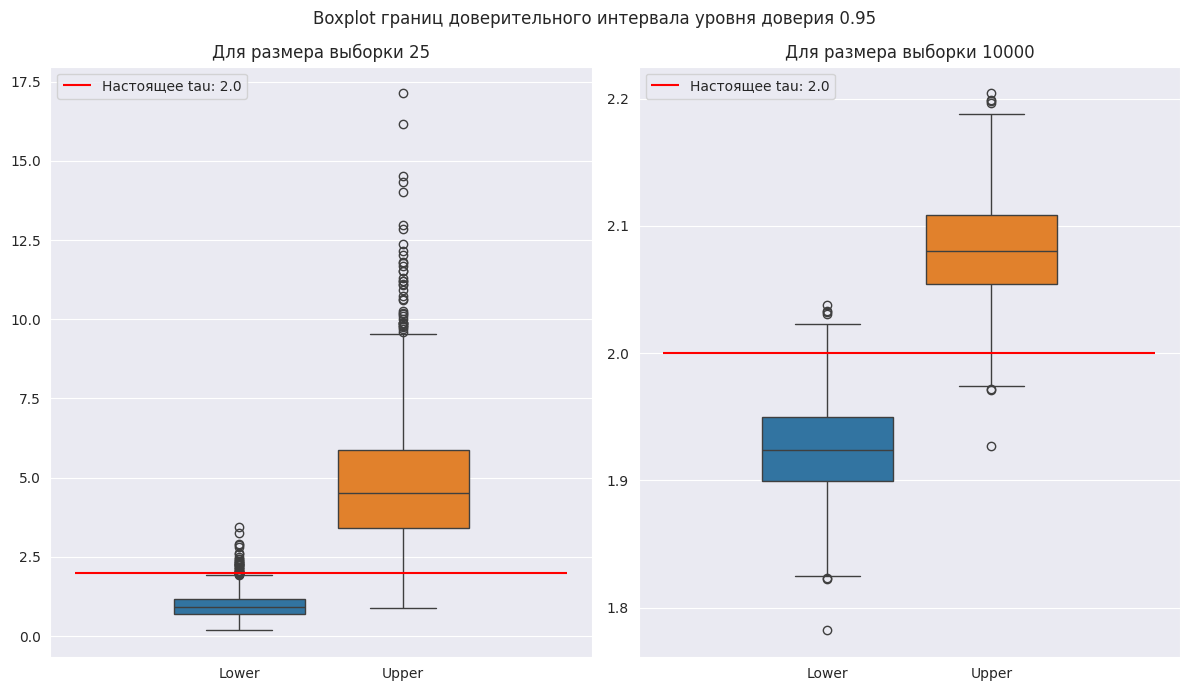

In [136]:
def draw_plot_1(data_small, data_large):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
    fig.suptitle(f"Boxplot границ доверительного интервала уровня доверия {1 - alpha}")

    plot1 = sns.boxplot(data_small, ax=ax1)
    plot1.hlines(tau, xmin = -1, xmax = 2, colors = ["Red"], label = f"Настоящее tau: {tau}")
    plot1.set_title(f"Для размера выборки {n_small}")
    ax1.legend()

    plot2 = sns.boxplot(data_large, ax=ax2)
    plot2.hlines(tau, xmin = -1, xmax = 2, colors = ["Red"], label = f"Настоящее tau: {tau}")
    plot2.set_title(f"Для размера выборки {n_large}")
    ax2.legend()

    plt.legend()
    plt.tight_layout()
    plt.show()
draw_plot_1(data_small, data_large)

При малых выборках доля интервалов, содержащих истинное значение, может отклоняться от 95%, но по мере увеличения размера выборки покрытие стремится к 95%.

При увеличении выборки доверительные интервалы становятся уже. Это связано с уменьшением разброса оценки отношения дисперсий и тем, что статистика стабилизируется при больших размерах выборки.

С ростом объема выборки доверительные интервалы становятся точнее и стабильнее - уже и покрытие ближе к заданному уровню.

## Задание 2

### Исходные данные
- Распределение $\text{Exp}(\lambda),\ \lambda=1$

### Немного теории
>**Плотность $\text{Exp}(\lambda)$**:
$$
f(x; \lambda) =
\begin{cases}
\lambda e^{-\lambda x}, \quad x \geq 0\\
0, \quad x \le 0
\end{cases}
$$

>**Функция $\text{Exp}(\lambda)$**:
$$
F(x; \lambda) =
\begin{cases}
1 - e^{-\lambda x}, \quad x \geq 0\\
0, \quad x \le 0
\end{cases}
$$

>**Медиана** — это значение $m$, такое что:
$$
P(X \leq m) = 0.5.
$$

Доверительный интервал
Пусть $ X_1, X_2, \ldots, X_n $ — независимые и одинаково распределённые случайные величины с функцией плотности $f(x)$, а $ \hat{m} $ - выборочная медиана:
$$
\hat{m} = \text{med}(X_1, X_2, \ldots, X_n)
$$
По Центральной предельной теореме, при $n\to\infty$ выборочная медиана $\hat{m}$ имеет асимптотически нормальное распределение:
$$
\sqrt{n} \left( \hat{m} - m \right) \xrightarrow{d} \mathcal{N}\left(0, \frac{1}{4f(m)^2}\right)
$$

$$
2f(m)\sqrt{n}(\hat{m} - m) \xrightarrow{d} \mathcal{N}(0, 1)
$$

Используя квартили нормального распределения, получаем следующее.

$$
P(-z_{1-α/2} \le 2f(m)\sqrt{n}(\hat{m} - m) \le z_{1-α/2}) \approx 1 - \alpha
$$

$$
P\left(\hat{m}-\frac{z_{1-α/2}}{2f(m)\sqrt{n}} \le m \le \hat{m}+\frac{z_{1-α/2}}{2f(m)\sqrt{n}}\right) \approx 1 - \alpha
$$

Теперь построим доверительный интервал уровня доверия $1 - \alpha:$

$$
\boxed{
m \in \left[ \hat{m}-\frac{z_{1-α/2}}{2f(m)\sqrt{n}}, \hat{m}+\frac{z_{1-α/2}}{2f(m)\sqrt{n}}\right]
}
$$

### Медиана для экспоненциального распределения
Вычислим $f(m)$ для экспоненциального распределения.

Теоретическое значение медианы для экспоненциального распеределения.

$$
P(X \leq m) = 1 - e^{-\lambda m} = 0.5
$$

Из чего следует:

$$
e^{-\lambda m} = 0.5 \quad \Rightarrow \quad -\lambda m = \ln(0.5) \quad \Rightarrow \quad m = \frac{\ln(2)}{\lambda}
$$

Таким образом, медиана экспоненциального распределения:

$$
m = \frac{\ln(2)}{\lambda}
$$

Подставляя это значение в функцию плотности получим:

$$
f(m) = \lambda e^{-\lambda \cdot \frac{\ln(2)}{\lambda}} = \lambda e^{-\ln(2)} = \lambda \cdot \frac{1}{2} = \frac{\lambda}{2}
$$

Подставляя полученное значения $f(m)$ в ранее выведенную формулу получим:

$$
m \in \left[ \hat{m}-\frac{z_{1-α/2}}{2\frac{\lambda}{2}\sqrt{n}}, \hat{m}+\frac{z_{1-α/2}}{2\frac{\lambda}{2}\sqrt{n}}\right]
$$

Что после простейших преобразований даёт итоговую формулу:

$$
\boxed{
m \in \left[ \hat{m}-\frac{z_{1-α/2}}{\lambda\sqrt{n}}, \hat{m}+\frac{z_{1-α/2}}{\lambda\sqrt{n}}\right]
}
$$

Так как по условию $\lambda = 1$:
 $$
\boxed{
m \in \left[ \hat{m}-\frac{z_{1-α/2}}{\sqrt{n}}, \hat{m}+\frac{z_{1-α/2}}{\sqrt{n}}\right]
}
$$





In [137]:
lambda_ours = 1
m = np.log(2)
z = norm.ppf(1-alpha/2)

In [138]:
def simulate_experiment_2(n):
    coverage = 0
    lows = []
    highs = []
    for i in range(experiments):
        X = np.random.exponential(scale=1/lambda_ours, size=n)
        m_ours = np.median(X)

        CI_low = m_ours - z/np.sqrt(n)
        CI_high = m_ours + z/np.sqrt(n)

        lows.append(CI_low)
        highs.append(CI_high)

        if CI_low <= m <= CI_high:
            coverage += 1

    ci_df = pd.DataFrame(np.vstack((lows, highs)).T, columns=['Lower', 'Upper'])
    coverage_prob = coverage / experiments

    return coverage_prob, ci_df

coverage_small, data_small = simulate_experiment_2(n_small)
coverage_large, data_large = simulate_experiment_2(n_large)

print(f"Доля покрытий для n={n_small}: {coverage_small:.4f}")
print(f"Доля покрытий для n={n_large}: {coverage_large:.4f}")

Доля покрытий для n=25: 0.9440
Доля покрытий для n=10000: 0.9450


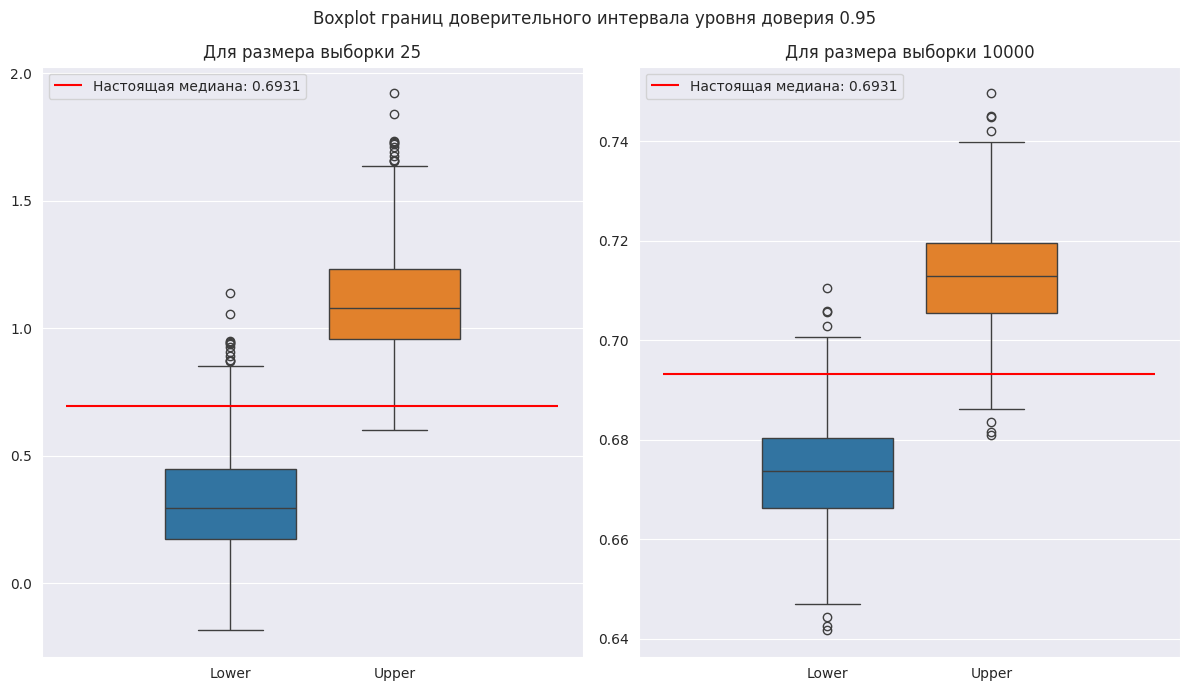

In [139]:
def draw_plot_2(combined_data_small, combined_data_large):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
  fig.suptitle(f"Boxplot границ доверительного интервала уровня доверия {1 - alpha}")

  plot1 = sns.boxplot(combined_data_small, ax=ax1)
  plot1.hlines(m, xmin = -1, xmax = 2, colors = ["Red"], label = f"Настоящая медиана: {m:.4f}")
  plot1.set_title(f"Для размера выборки {n_small}")
  ax1.legend()

  plot2 = sns.boxplot(combined_data_large, ax=ax2)
  plot2.hlines(m, xmin = -1, xmax = 2, colors = ["Red"], label = f"Настоящая медиана: {m:.4f}")
  plot2.set_title(f"Для размера выборки {n_large}")
  ax2.legend()

  plt.legend()
  plt.tight_layout()
  plt.show()

draw_plot_2(data_small, data_large)

При обоих объемах выборки доля интервалов, содержащих истинную медиану составляет примерно 95%. Это подтверждает корректность использования ЦПТ и асимптотической нормальности при оценке медианы.

При увеличении выборки дисперсия оценки медианы уменьшается, интервал становится уже, точность выше.